# Handling Unstructured Data: Images, Text, and Graphs

**Author:** Phabel Antonio López Delgado, BSc.

This notebook explores how to handle unstructured data – data that lacks a predefined organization or structure. We cover three common types of unstructured data:

1. **Images** – represented as tensors of pixel values (grayscale, RGB, RGBA).
2. **Text** – represented as sequences of tokens with embeddings.
3. **Graphs** – represented as adjacency matrices and node features.

**Key Concepts Covered:**
- Image representation: grayscale (2D), RGB (3D), RGBA (4D).
- Flattening images for machine learning models.
- Text tokenization and vocabulary creation.
- Word embeddings and training embeddings for a task.
- Graph representation using adjacency matrices.
- Visualisation of images, embeddings, and graphs.

**Key Techniques & Libraries:**
- `sklearn.datasets` – loading sample images and digits.
- `matplotlib` – visualisation.
- `torch` – embeddings and neural networks.
- `networkx` – graph creation and visualisation.
- `collections` – vocabulary mapping.

**Objective:**
To understand how unstructured data (images, text, graphs) is represented in a format suitable for machine learning and deep learning models.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, load_sample_images
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from collections import defaultdict, Counter
from tqdm import tqdm
import networkx as nx

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("All imports successful.")

All imports successful.


## 1. Images

Images are represented as matrices of pixels. In the simplest case (grayscale), a pixel is a single numerical value, so the image is a matrix of size \( H \times W \), where \( H \) is height and \( W \) is width in pixels.

For colour images, each pixel is a vector:
- **RGB**: 3 channels (red, green, blue) → tensor of size \( H \times W \times 3 \).
- **RGBA**: 4 channels (RGB + alpha for transparency) → tensor of size \( H \times W \times 4 \).

### Example: MNIST Digits (Grayscale)

In [2]:
# Load the digits dataset (8x8 grayscale images)
data = load_digits()
X = data.data.reshape(1797, 8, 8)  # images
y = data.target                   # labels

print(f"Image shape: {X[0].shape}")
print(f"Pixel values:\n{X[0]}")

Image shape: (8, 8)
Pixel values:
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]


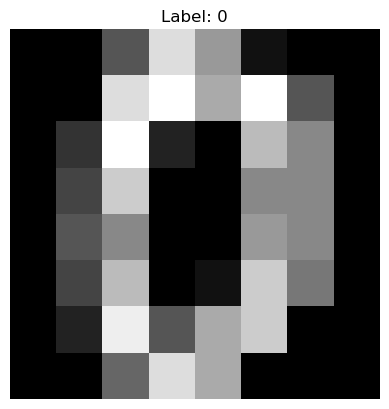

In [3]:
# Visualise the first digit
plt.imshow(X[0], cmap='gray')
plt.title(f"Label: {y[0]}")
plt.axis('off')
plt.show()

### Example: RGB Image

We load a sample colour image from scikit‑learn. Each pixel is a 3‑dimensional vector (R, G, B).

In [4]:
# Load sample images (RGB)
images = load_sample_images().images
img = images[0]

print(f"Image shape: {img.shape}")  # (height, width, channels)
print(f"First pixel (RGB): {img[0, 0]}")

Image shape: (427, 640, 3)
First pixel (RGB): [174 201 231]


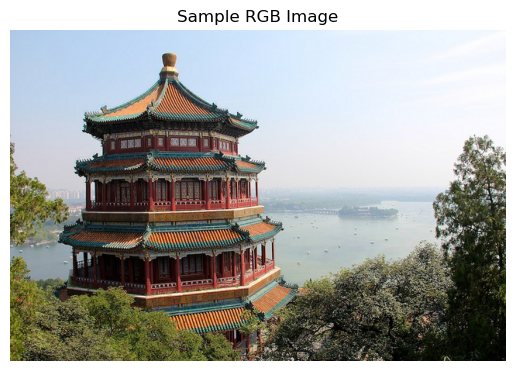

In [5]:
plt.imshow(img)
plt.title("Sample RGB Image")
plt.axis('off')
plt.show()

### 1.1 Flattening Images

Flattening transforms a 2D or 3D tensor into a 1D vector. For a grayscale image of size \( H \times W \), the flattened vector has size \( H \cdot W \). This allows the image to be used as input for models that expect vectors (e.g., perceptron, MLP).

However, flattening loses spatial information: if the image is translated or rotated, the flattened vector changes, even though the content is the same.

In [6]:
H, W = X[0].shape
flattened = X[0].reshape(H * W)

print(f"Original shape: {H} x {W}")
print(f"Flattened shape: {flattened.shape}")
print(f"Flattened vector:\n{flattened}")

Original shape: 8 x 8
Flattened shape: (64,)
Flattened vector:
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]


### 1.2 Training a Perceptron on Flattened Images

We flatten all images and train a perceptron for digit classification.

In [7]:
# Flatten all images
X_flat = X.reshape(len(X), H * W)
print(f"Flattened dataset shape: {X_flat.shape}")

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_flat, y, test_size=0.3, random_state=42)

# Train a perceptron
model = Perceptron(eta0=0.01, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

Flattened dataset shape: (1797, 64)
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        53
           1       0.97      0.62      0.76        50
           2       0.94      0.98      0.96        47
           3       0.98      0.93      0.95        54
           4       0.95      0.97      0.96        60
           5       0.98      0.88      0.93        66
           6       0.98      0.98      0.98        53
           7       0.96      0.98      0.97        55
           8       0.67      0.95      0.79        43
           9       0.84      0.95      0.89        59

    accuracy                           0.92       540
   macro avg       0.93      0.92      0.92       540
weighted avg       0.93      0.92      0.92       540



## 2. Text Data

Text data is more complex than images because it is not naturally represented as tensors. We must first **tokenise** the text (split into tokens, e.g., words or subwords), then assign each token a numerical index.

### 2.1 Vocabulary and Tokenisation

We create a vocabulary that maps each unique token to an integer. We also add special tokens:
- `BOS` (beginning of sequence)
- `EOS` (end of sequence)

In [8]:
def create_vocabulary():
    """Create a default dictionary that assigns a new index to each new token."""
    vocab = defaultdict()
    vocab.default_factory = lambda: len(vocab)
    return vocab

def text_to_indices(corpus, vocab):
    """
    Convert a list of text documents to sequences of token indices.
    Each document is prefixed with 'BOS' and suffixed with 'EOS'.
    """
    for doc in corpus:
        tokens = ['BOS'] + doc.split() + ['EOS']
        yield torch.tensor([vocab[token] for token in tokens], dtype=torch.long)

In [9]:
# Sample text data
text_data = [
    'el perro come un hueso',
    'un muchacho jugaba',
    'el muchacho saltaba la cuerda',
    'un perro come croquetas',
    'el perro come',
    'el gato come croquetas',
    'un gato come'
]

# Create vocabulary
vocab = create_vocabulary()
vocab['BOS'] = 0
vocab['EOS'] = 1

# Convert text to indices
indices_data = list(text_to_indices(text_data, vocab))

print("Vocabulary:", dict(vocab))
print("\nFirst document (indices):", indices_data[0])
print("First document (tokens):", ['BOS'] + text_data[0].split() + ['EOS'])

Vocabulary: {'BOS': 0, 'EOS': 1, 'el': 2, 'perro': 3, 'come': 4, 'un': 5, 'hueso': 6, 'muchacho': 7, 'jugaba': 8, 'saltaba': 9, 'la': 10, 'cuerda': 11, 'croquetas': 12, 'gato': 13}

First document (indices): tensor([0, 2, 3, 4, 5, 6, 1])
First document (tokens): ['BOS', 'el', 'perro', 'come', 'un', 'hueso', 'EOS']


### 2.2 Word Embeddings

Embeddings are dense vector representations of tokens. Instead of using one‑hot vectors (which are high‑dimensional and sparse), embeddings map each token to a lower‑dimensional continuous vector. These vectors are learned during training and capture semantic relationships between tokens.

In PyTorch, we use `nn.Embedding(vocab_size, embedding_dim)`.

In [10]:
vocab_size = len(vocab)
embedding_dim = 2  # small for visualisation

# Create embedding layer
embedding_layer = nn.Embedding(vocab_size, embedding_dim)

# Get embeddings for the first document
doc_indices = indices_data[0]
embeddings = embedding_layer(doc_indices)

print(f"Document indices: {doc_indices}")
print(f"Embeddings shape: {embeddings.shape}")
print(f"Embeddings:\n{embeddings}")

Document indices: tensor([0, 2, 3, 4, 5, 6, 1])
Embeddings shape: torch.Size([7, 2])
Embeddings:
tensor([[ 1.9269,  1.4873],
        [ 0.6784, -1.2345],
        [-0.0431, -1.6047],
        [-0.7521,  1.6487],
        [-0.3925, -1.4036],
        [-1.1109,  0.0915],
        [ 0.9007, -2.1055]], grad_fn=<EmbeddingBackward0>)


### 2.3 Visualising Embeddings (Before Training)

Initially, embeddings are randomly initialised, so tokens with similar meanings are not necessarily close in the vector space.

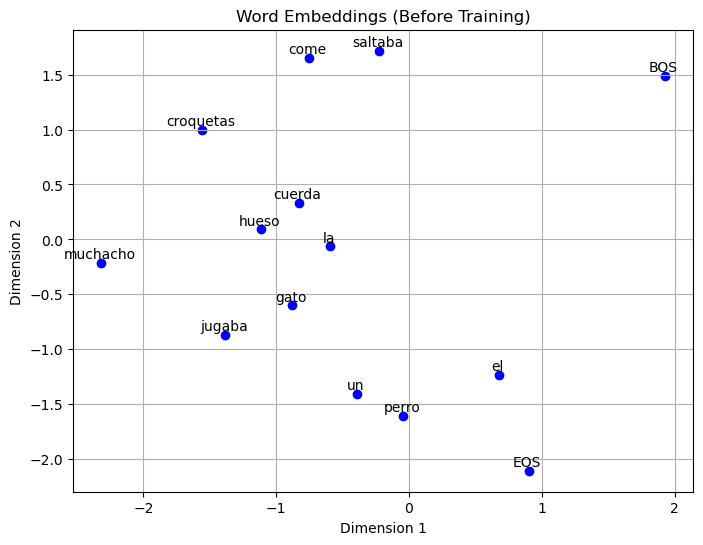

In [11]:
def plot_embeddings(embedding_weights, token_names):
    """Plot 2D embeddings with token labels."""
    plt.figure(figsize=(8, 6))
    plt.scatter(embedding_weights[:, 0], embedding_weights[:, 1], marker='o', c='blue')
    for label, x, y in zip(token_names, embedding_weights[:, 0], embedding_weights[:, 1]):
        plt.annotate(label, xy=(x, y), xytext=(-1, 1), textcoords='offset points',
                     ha='center', va='bottom')
    plt.title("Word Embeddings (Before Training)")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.grid(True)
    plt.show()

# Plot initial (random) embeddings
plot_embeddings(embedding_layer.weight.detach().numpy(), vocab.keys())

### 2.4 Training Embeddings on a Task

We train the embeddings on a **next‑token prediction** task. The model learns to predict the next token in a sequence. During training, the embedding vectors are updated to capture meaningful relationships.

The architecture:
- Embedding layer: maps token indices to vectors.
- Linear layer: maps the embedding to logits over the vocabulary.
- Softmax: converts logits to probabilities.

Loss: Cross‑entropy between predicted next token and actual next token.

In [12]:
# Model: embedding + linear classifier
class NextTokenPredictor(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.linear = nn.Linear(embedding_dim, vocab_size)

    def forward(self, x):
        embedded = self.embedding(x)
        logits = self.linear(embedded)
        return logits

# Instantiate model
model = NextTokenPredictor(vocab_size, embedding_dim)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop
epochs = 100
for epoch in tqdm(range(epochs)):
    for doc_indices in indices_data:
        # Input: all tokens except last, target: all tokens except first
        inputs = doc_indices[:-1]
        targets = doc_indices[1:]

        # Forward pass
        logits = model(inputs)
        loss = criterion(logits, targets)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

print("Training complete.")

100%|██████████| 100/100 [00:00<00:00, 211.38it/s]

Training complete.


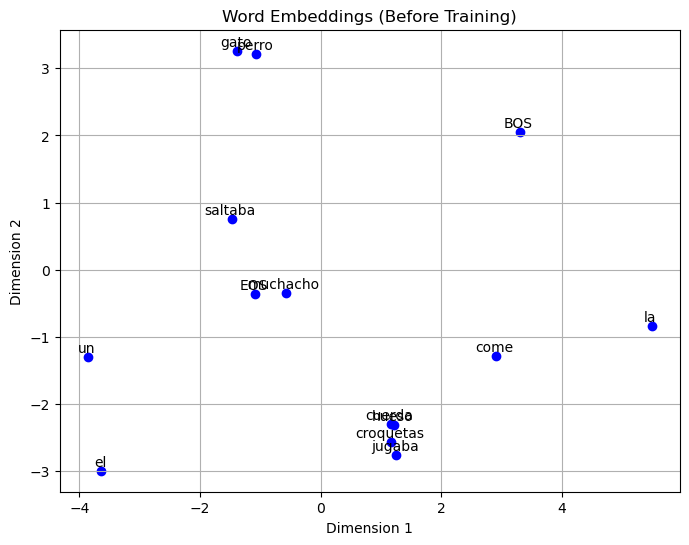

In [13]:
# Extract trained embeddings
trained_weights = model.embedding.weight.detach().numpy()

# Plot
plot_embeddings(trained_weights, vocab.keys())

## 3. Graph Data

Graphs are a powerful way to represent relationships between entities. A graph consists of:
- **Nodes** (vertices) representing entities.
- **Edges** representing relationships between nodes.

Edges can be weighted (with a numerical value) or unweighted. Graphs are often represented by an **adjacency matrix** $A$, where $A_{i,j}$ indicates the connection between node $i$ and node $j$.

For a weighted graph, $A_{i,j}$ is the weight of the edge; for an unweighted graph, it is 0 or 1.

Graphs are unstructured because the number of nodes and edges can vary, and there is no fixed ordering of nodes.

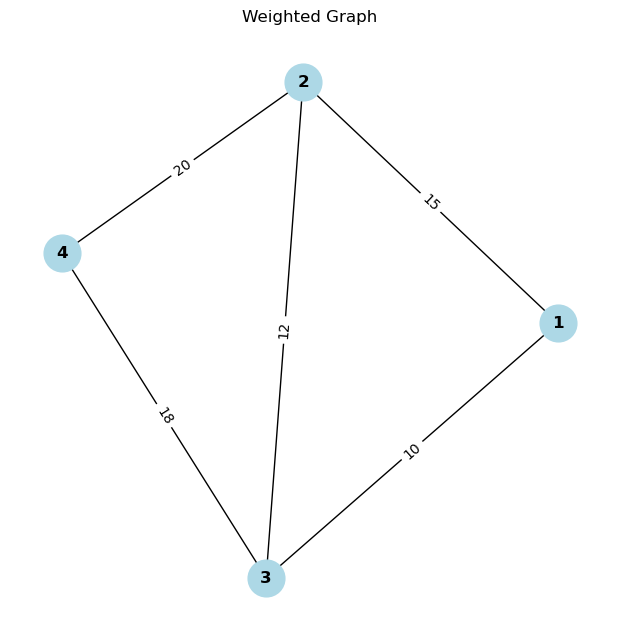

In [14]:
# Create a weighted graph
G = nx.Graph()

# Add edges with weights
G.add_edge(1, 2, weight=15)
G.add_edge(1, 3, weight=10)
G.add_edge(3, 4, weight=18)
G.add_edge(2, 4, weight=20)
G.add_edge(2, 3, weight=12)

# Visualise the graph
pos = nx.spring_layout(G, seed=42)
edge_labels = nx.get_edge_attributes(G, "weight")

plt.figure(figsize=(6, 6))
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=700, font_weight='bold')
nx.draw_networkx_edge_labels(G, pos, edge_labels)
plt.title("Weighted Graph")
plt.show()

In [15]:
# Convert graph to adjacency matrix
A = nx.to_numpy_array(G)
print("Adjacency Matrix (weighted):")
print(A)

Adjacency Matrix (weighted):
[[ 0. 15. 10.  0.]
 [15.  0. 12. 20.]
 [10. 12.  0. 18.]
 [ 0. 20. 18.  0.]]


### 3.1 Graph Neural Networks (Brief Introduction)

In deep learning, graph data is often processed by **Graph Neural Networks (GNNs)** . In a GNN:
- Each node has a feature vector (embedding).
- The adjacency matrix defines how nodes are connected.
- The model updates node representations by aggregating information from neighbours.

While we do not implement a full GNN here, the adjacency matrix is the fundamental representation that enables such models.

## Summary and Next Steps

**Accomplished:**
- Explored image representation: grayscale, RGB, RGBA.
- Flattened images and trained a perceptron for digit classification.
- Tokenised text data and created a vocabulary.
- Created and visualised word embeddings (before and after training).
- Trained embeddings on a next‑token prediction task.
- Built and visualised a weighted graph and its adjacency matrix.

**Key Insights:**
- Images are naturally represented as tensors; flattening loses spatial information but enables use with standard ML models.
- Text data must be tokenised and mapped to indices before it can be processed.
- Embeddings provide dense, learnable representations of tokens that capture semantic relationships.
- Training embeddings on a task (e.g., next‑token prediction) yields meaningful representations.
- Graphs are represented by adjacency matrices, which encode relational structure.

**Suggested Next Steps:**
1. **Use a CNN for image classification** – instead of flattening, preserve spatial structure.
2. **Train a word2vec-style model** – train embeddings on a larger corpus.
3. **Apply a Graph Neural Network** – use `torch_geometric` or `dgl` to build a GNN.
4. **Combine modalities** – build a model that processes both images and text.

**Reflection:**
Unstructured data (images, text, graphs) requires careful preprocessing before it can be used in machine learning models. Understanding how to represent and transform these data types is essential for tackling real‑world problems. This notebook provides a solid foundation for working with each type and preparing it for deep learning models.